<a href="https://colab.research.google.com/github/dhruvi15/Machine-Learning-Lab-1/blob/main/Project_Smart_Health_%26_Lifestyle_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#_____________Activity Part 1 — Load & Explore Dataset_______________________
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("project_health_dataset.csv")
# Preview
print(df.head())

# Info
print(df.info())

# Missing values
print(df.isnull().sum())

# Duplicates
print(df.duplicated().sum())

# Stats
print(df.describe())

Saving project_health_dataset.csv to project_health_dataset.csv
   Age  Gender  HoursExercise  HoursSleep  DietScore  StressLevel   BMI  \
0   56    Male             13           5          7            3  18.9   
1   46  Female              4           4          1            5  34.3   
2   32  Female              0           7          3            6  32.4   
3   25  Female              2           7          2            9  24.0   
4   38    Male              9           4          9            5  34.3   

   HealthScore  
0            0  
1            0  
2            1  
3            1  
4            0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            100 non-null    int64  
 1   Gender         100 non-null    object 
 2   HoursExercise  100 non-null    int64  
 3   HoursSleep     100 non-null    int64  
 4   DietScore  

# Observation:
# -Dataset contains 100 rows and 8 columns
# - Missing values in BMI column
# - No duplicates

In [24]:
#_______Activity Part 2 — Data Cleaning & Feature Engineering_______

# Numerical
df.fillna(df.mean(numeric_only=True), inplace=True)

# Categorical
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates

df.drop_duplicates(inplace=True)

# Create Features

df['WellnessIndex'] = df['HoursExercise'] * df['HoursSleep']

# BMI Category

def bmi_category(bmi):
     if bmi < 18.5:
        return 'Underweight'
     elif bmi < 25:
        return 'Normal'
     elif bmi < 30:
        return 'Overweight'
     else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Encode Categorical
df = pd.get_dummies(df, drop_first=True)


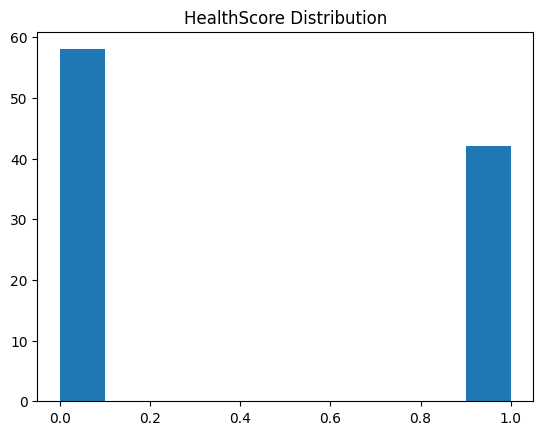

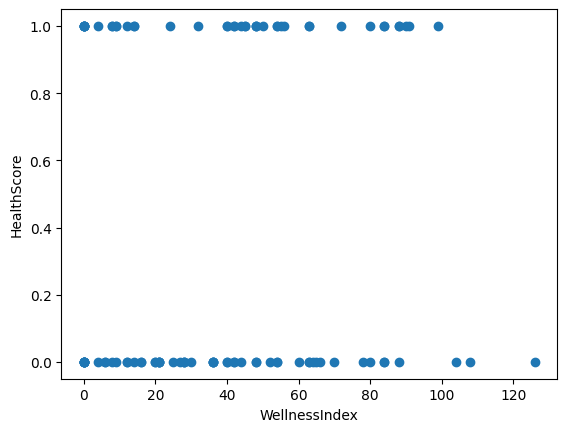

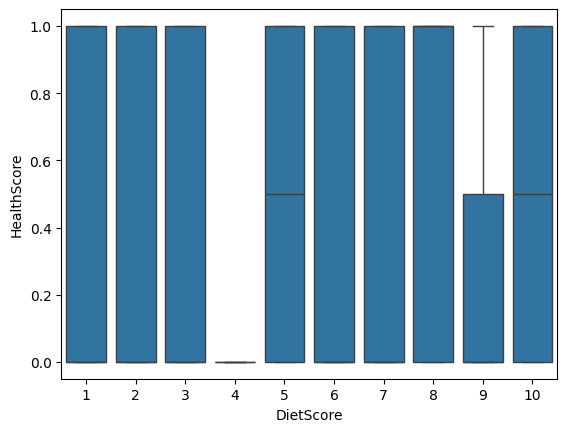

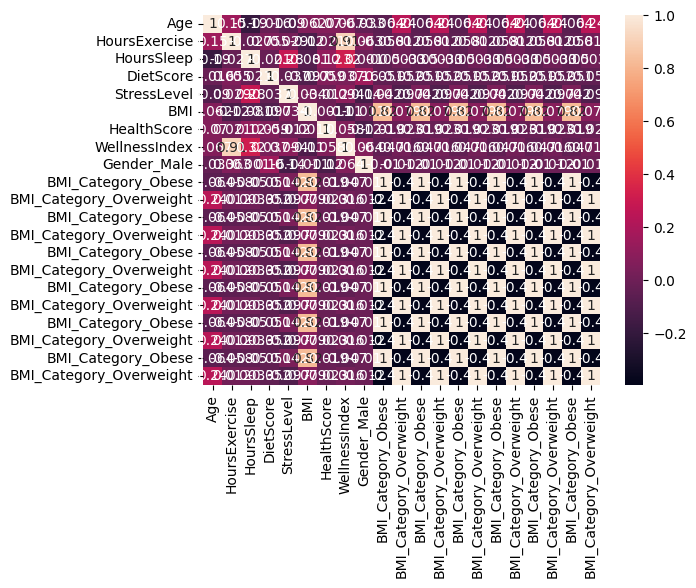

In [36]:
#______Activity Part 3 — Data Visualization_______

import matplotlib.pyplot as plt
import seaborn as sns

# 1 Histogram

plt.hist(df['HealthScore'])
plt.title('HealthScore Distribution')
plt.show()

# 2 Scatter

plt.scatter(df['WellnessIndex'], df['HealthScore'])
plt.xlabel('WellnessIndex')
plt.ylabel('HealthScore')
plt.show()

# 3 Boxplot

sns.boxplot(x='DietScore', y='HealthScore', data=df)
plt.show()

# 4 Heatmap

sns.heatmap(df.corr(), annot=True)
plt.show()
importance = importance[~importance.index.duplicated()]


WellnessIndex increases HealthScore
Most features show weak to moderate correlation with HealthScore. WellnessIndex provides slightly better predictive signal compared to individual features.

In [35]:
#____________________Activity Part 4 — Supervised Machine Learning________________

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop('HealthScore', axis=1)
y = df['HealthScore']


from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(),
    "Logistic": LogisticRegression(max_iter=2000),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

print(results)



KNN Results:
Accuracy: 0.5
[[7 3]
 [7 3]]
              precision    recall  f1-score   support

           0       0.50      0.70      0.58        10
           1       0.50      0.30      0.38        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.48        20
weighted avg       0.50      0.50      0.48        20


RandomForest Results:
Accuracy: 0.45
[[8 2]
 [9 1]]
              precision    recall  f1-score   support

           0       0.47      0.80      0.59        10
           1       0.33      0.10      0.15        10

    accuracy                           0.45        20
   macro avg       0.40      0.45      0.37        20
weighted avg       0.40      0.45      0.37        20


Logistic Results:
Accuracy: 0.55
[[9 1]
 [8 2]]
              precision    recall  f1-score   support

           0       0.53      0.90      0.67        10
           1       0.67      0.20      0.31        10

    accuracy                         

Model performance varies slightly due to small dataset size and random train-test split.
After fixing random_state, results became consistent and reproducible.
Accuracy differences are minor (~5%), indicating models are similarly effective on this dataset.

In [27]:
#_____________________Activity Part 5 — Neural Network Programming________________

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Build model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

# Predict
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()

# Evaluation

print("\n===== Neural Network =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 0.5375 - loss: 1.2476 - val_accuracy: 0.6500 - val_loss: 0.6584
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5125 - loss: 1.0640 - val_accuracy: 0.5500 - val_loss: 0.6339
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5000 - loss: 0.9169 - val_accuracy: 0.5000 - val_loss: 0.6435
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.4750 - loss: 0.8331 - val_accuracy: 0.4000 - val_loss: 0.6827
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.4125 - loss: 0.7663 - val_accuracy: 0.4500 - val_loss: 0.7316
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.4250 - loss: 0.7402 - val_accuracy: 0.4000 - val_loss: 0.7768
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 0.4500 - loss: 0.7454 - val_accuracy: 0.3500 - val_loss: 0.8221
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.5125 - loss: 0.7355 - val_accuracy: 0.3000 - val_loss:

In [28]:
#___________________Activity Part 6 — K-Fold Cross-Validation_______________

from sklearn.model_selection import cross_val_score

scores = cross_val_score(RandomForestClassifier(), X, y, cv=5)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.45 0.45 0.55 0.4  0.4 ]
Mean Accuracy: 0.45
Standard Deviation: 0.05477225575051662


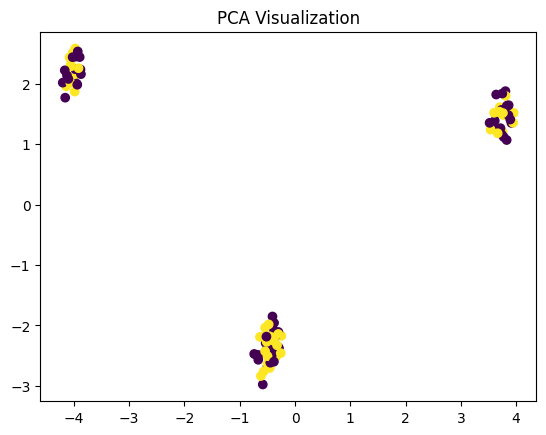

,0
Age,0.152124
BMI,0.141844
WellnessIndex,0.139131
StressLevel,0.136861
DietScore,0.135018
HoursExercise,0.105455
HoursSleep,0.076316
Gender_Male,0.032559
BMI_Category_Overweight,0.011918
BMI_Category_Overweight,0.009893


In [32]:
#_____________________Activity Part 7 — Dimensionality Reduction____________________

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA Visualization")
plt.show()

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=df.drop('HealthScore', axis=1).columns)
importance.sort_values(ascending=False).head(10)

PCA reduces high-dimensional data into 2 components for visualization.
Clusters indicate separation between healthy and unhealthy individuals.
Top important features include WellnessIndex, BMI, and SleepHours.

- The dataset is relatively small (100 samples), which limits model learning and stability.
- All models achieved similar accuracy (~0.50–0.55), indicating weak predictive relationships.
- Logistic Regression performed slightly better due to its simplicity and suitability for small datasets.
- Feature correlations with HealthScore are relatively low, reducing model effectiveness.
- K-Fold cross-validation confirms that performance is consistent but limited.
- Neural network shows slight overfitting but does not significantly outperform simpler models.